**Marketing Sales Revenue Prediction Using Linear Regression**

Topic:
Effect of Marketing Activities on Sales Revenue with Brand Loyalty
as a Moderating Variable

In [23]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

In [24]:
# ============================================================
# STEP 2: VARIABLE DESIGN
# ============================================================

print("Dependent Variable / Target:")
print(". sales_revenue")

print("\nIndependent Variables:")
print(". ad_spend")
print(". discount_percent")
print(". email_click_rate")
print(". social_media_engagement")
print(". website_visits")
print(". customer_rating")

print("\nModerating Variable:")
print(". brand_loyalty_score")

print("\nControlled Variables:")
print(". customer_age")
print(". previous_purchase_amount")
print(". income_level")

print("\nInteraction Term:")
print(". ad_spend_x_brand_loyalty = ad_spend * brand_loyalty_score")

Dependent Variable / Target:
. sales_revenue

Independent Variables:
. ad_spend
. discount_percent
. email_click_rate
. social_media_engagement
. website_visits
. customer_rating

Moderating Variable:
. brand_loyalty_score

Controlled Variables:
. customer_age
. previous_purchase_amount
. income_level

Interaction Term:
. ad_spend_x_brand_loyalty = ad_spend * brand_loyalty_score


In [25]:
# ============================================================
# STEP 3: CREATE 6000-ROW MARKETING DATASET
# ============================================================

n = 8000

customer_id = [f"CUST_{i:05d}" for i in range(1, n + 1)]

# Independent variables
ad_spend = np.clip(np.random.normal(4500, 1800, n), 500, 12000).round(0)
discount_percent = np.clip(np.random.normal(12, 6, n), 0, 35).round(1)
email_click_rate = np.clip(np.random.normal(0.12, 0.06, n), 0.01, 0.40).round(3)
social_media_engagement = np.clip(np.random.normal(55, 20, n), 5, 100).round(1)
website_visits = np.clip(np.random.normal(180, 75, n), 10, 500).round(0)
customer_rating = np.clip(np.random.normal(3.8, 0.7, n), 1, 5).round(1)

# Moderating variable
brand_loyalty_score = np.clip(np.random.normal(3.2, 1.0, n), 1, 5).round(1)

# Controlled variables
customer_age = np.random.randint(18, 61, n)
previous_purchase_amount = np.clip(np.random.normal(7000, 3500, n), 0, 30000).round(0)
income_level = np.clip(np.random.normal(55000, 18000, n), 15000, 150000).round(0)

# Interaction term for moderation
ad_loyalty_interaction = ad_spend * brand_loyalty_score

# Random noise
noise = np.random.normal(0, 1200, n)

# Target variable: sales revenue
sales_revenue = (
    2500
    + 0.85 * ad_spend
    + 95 * discount_percent
    + 9000 * email_click_rate
    + 22 * social_media_engagement
    + 14 * website_visits
    + 480 * customer_rating
    + 350 * brand_loyalty_score
    + 0.11 * previous_purchase_amount
    + 0.015 * income_level
    + 0.08 * ad_loyalty_interaction
    + noise
)

sales_revenue = np.clip(sales_revenue, 1000, None).round(2)

# Create dataframe
df = pd.DataFrame({
    "customer_id": customer_id,
    "ad_spend": ad_spend.astype(int),
    "discount_percent": discount_percent,
    "email_click_rate": email_click_rate,
    "social_media_engagement": social_media_engagement,
    "website_visits": website_visits.astype(int),
    "customer_rating": customer_rating,
    "brand_loyalty_score": brand_loyalty_score,
    "customer_age": customer_age,
    "previous_purchase_amount": previous_purchase_amount.astype(int),
    "income_level": income_level.astype(int),
    "sales_revenue": sales_revenue
})

df.head()

,customer_id,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,brand_loyalty_score,customer_age,previous_purchase_amount,income_level,sales_revenue
0,CUST_00001,5394,11.8,0.173,41.6,235,3.5,3.8,45,2882,36384,19683.92
1,CUST_00002,4251,9.0,0.122,40.7,59,4.5,2.5,29,5504,61608,16100.97
2,CUST_00003,5666,11.0,0.065,83.5,129,3.7,2.9,22,3144,74619,19774.99
3,CUST_00004,7241,16.3,0.092,92.3,77,3.9,3.0,32,6776,40698,16884.90
4,CUST_00005,4079,19.7,0.141,36.4,194,4.3,3.2,49,4492,65581,16599.87


In [26]:
df

,customer_id,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,brand_loyalty_score,customer_age,previous_purchase_amount,income_level,sales_revenue
0,CUST_00001,5394,11.8,0.173,41.6,235,3.5,3.8,45,2882,36384,19683.92
1,CUST_00002,4251,9.0,0.122,40.7,59,4.5,2.5,29,5504,61608,16100.97
2,CUST_00003,5666,11.0,0.065,83.5,129,3.7,2.9,22,3144,74619,19774.99
3,CUST_00004,7241,16.3,0.092,92.3,77,3.9,3.0,32,6776,40698,16884.90
4,CUST_00005,4079,19.7,0.141,36.4,194,4.3,3.2,49,4492,65581,16599.87
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,CUST_07996,8478,14.8,0.190,89.0,264,3.3,4.2,29,3664,58780,26202.15
7996,CUST_07997,5089,19.1,0.160,38.1,200,2.9,4.6,43,10384,91617,23135.97
7997,CUST_07998,2997,10.3,0.133,70.8,226,3.7,3.3,23,5897,47440,16485.61
7998,CUST_07999,7475,15.9,0.132,64.3,241,3.5,2.6,27,5536,62353,20841.47


In [27]:
# ============================================================
# STEP 4: CHECK DATASET SHAPE
# ============================================================

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
df.head()

Dataset shape: (8000, 12)

First 5 rows:


,customer_id,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,brand_loyalty_score,customer_age,previous_purchase_amount,income_level,sales_revenue
0,CUST_00001,5394,11.8,0.173,41.6,235,3.5,3.8,45,2882,36384,19683.92
1,CUST_00002,4251,9.0,0.122,40.7,59,4.5,2.5,29,5504,61608,16100.97
2,CUST_00003,5666,11.0,0.065,83.5,129,3.7,2.9,22,3144,74619,19774.99
3,CUST_00004,7241,16.3,0.092,92.3,77,3.9,3.0,32,6776,40698,16884.90
4,CUST_00005,4079,19.7,0.141,36.4,194,4.3,3.2,49,4492,65581,16599.87


In [28]:
# ============================================================
# STEP 5: DATA UNDERSTANDING
# ============================================================

print("Column names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Column names:
Index(['customer_id', 'ad_spend', 'discount_percent', 'email_click_rate',
       'social_media_engagement', 'website_visits', 'customer_rating',
       'brand_loyalty_score', 'customer_age', 'previous_purchase_amount',
       'income_level', 'sales_revenue'],
      dtype='object')

Data types:
customer_id                  object
ad_spend                      int64
discount_percent            float64
email_click_rate            float64
social_media_engagement     float64
website_visits                int64
customer_rating             float64
brand_loyalty_score         float64
customer_age                  int64
previous_purchase_amount      int64
income_level                  int64
sales_revenue               float64
dtype: object

Missing values:
customer_id                 0
ad_spend                    0
discount_percent            0
email_click_rate            0
social_media_engagement     0
website_visits              0
customer_rating             0
brand_loyalty_scor

In [29]:
# ============================================================
# STEP 6: STATISTICAL SUMMARY
# ============================================================

df.describe()

,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,brand_loyalty_score,customer_age,previous_purchase_amount,income_level,sales_revenue
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4502.556375,12.096700,0.120905,54.837187,179.564875,3.790538,3.196925,39.118250,7079.609125,55028.722625,17959.491538
std,1790.804490,5.851842,0.058062,19.577400,74.451109,0.675014,0.962553,12.350732,3405.764834,17933.856427,2849.743179
min,500.000000,0.000000,0.010000,5.000000,10.000000,1.000000,1.000000,18.000000,0.000000,15000.000000,7495.800000
25%,3280.000000,8.000000,0.079000,41.300000,127.000000,3.300000,2.500000,28.000000,4689.750000,42704.750000,16003.050000
50%,4487.500000,12.100000,0.120000,55.000000,179.000000,3.800000,3.200000,39.000000,7075.000000,55052.500000,17933.485000
75%,5711.000000,16.000000,0.161000,68.500000,230.000000,4.300000,3.900000,50.000000,9428.000000,67310.750000,19867.705000
max,11567.000000,35.000000,0.357000,100.000000,460.000000,5.000000,5.000000,60.000000,20498.000000,128806.000000,28488.340000


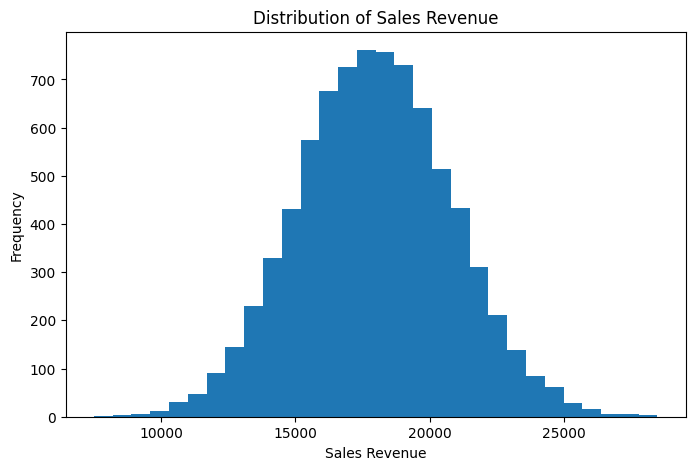

In [30]:
# ============================================================
# STEP 7: EDA - DISTRIBUTION OF SALES REVENUE
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["sales_revenue"], bins=30)
plt.xlabel("Sales Revenue")
plt.ylabel("Frequency")
plt.title("Distribution of Sales Revenue")
plt.show()

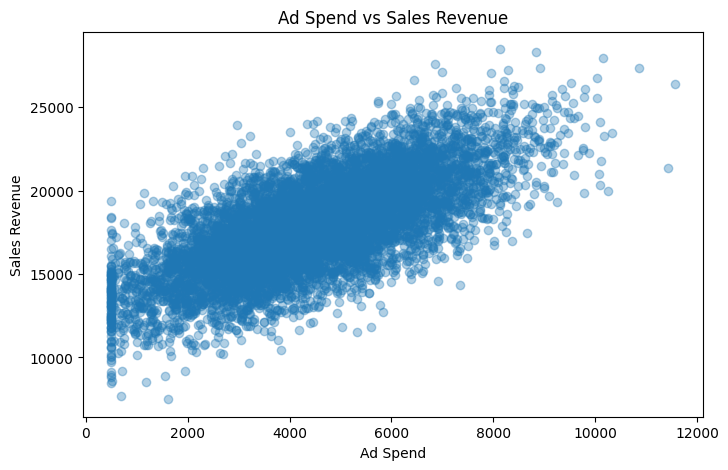

In [31]:
# ============================================================
# STEP 8: EDA - AD SPEND VS SALES REVENUE
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(df["ad_spend"], df["sales_revenue"], alpha=0.35)
plt.xlabel("Ad Spend")
plt.ylabel("Sales Revenue")
plt.title("Ad Spend vs Sales Revenue")
plt.show()

In [32]:
# ============================================================
# STEP 10: CORRELATION ANALYSIS
# ============================================================

numeric_df = df.drop(columns=["customer_id"])

correlation = numeric_df.corr(numeric_only=True)

correlation["sales_revenue"].sort_values(ascending=False)

,sales_revenue
sales_revenue,1.000000
ad_spend,0.702670
website_visits,0.361482
brand_loyalty_score,0.235650
discount_percent,0.203220
email_click_rate,0.167597
social_media_engagement,0.162660
previous_purchase_amount,0.133056
customer_rating,0.115048
income_level,0.098920


In [33]:
# ============================================================
# STEP 11: CREATE INTERACTION TERM FOR MODERATION
# ============================================================

df_model = df.copy()

df_model["ad_spend_x_brand_loyalty"] = (
    df_model["ad_spend"] * df_model["brand_loyalty_score"]
)

df_model.head()

,customer_id,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,brand_loyalty_score,customer_age,previous_purchase_amount,income_level,sales_revenue,ad_spend_x_brand_loyalty
0,CUST_00001,5394,11.8,0.173,41.6,235,3.5,3.8,45,2882,36384,19683.92,20497.2
1,CUST_00002,4251,9.0,0.122,40.7,59,4.5,2.5,29,5504,61608,16100.97,10627.5
2,CUST_00003,5666,11.0,0.065,83.5,129,3.7,2.9,22,3144,74619,19774.99,16431.4
3,CUST_00004,7241,16.3,0.092,92.3,77,3.9,3.0,32,6776,40698,16884.90,21723.0
4,CUST_00005,4079,19.7,0.141,36.4,194,4.3,3.2,49,4492,65581,16599.87,13052.8


In [37]:
# ============================================================
# STEP 12: DEFINE INPUT AND OUTPUT VARIABLES
# ============================================================

target = "sales_revenue"

# Model 1: without moderating variable
base_features = [
    "ad_spend",
    "discount_percent",
    "email_click_rate",
    "social_media_engagement",
    "website_visits",
    "customer_rating",
    "customer_age",
    "previous_purchase_amount",
    "income_level"
]

# Model 2: with moderating variable and interaction term
moderation_features = base_features + [
    "brand_loyalty_score",
    "ad_spend_x_brand_loyalty"
]

X_base = df_model[base_features]
X_mod = df_model[moderation_features]
y = df_model[target]

print("Model 1 Features Without Moderator:")
print(base_features)

print("\nModel 2 Features With Moderator:")
print(moderation_features)

Model 1 Features Without Moderator:
['ad_spend', 'discount_percent', 'email_click_rate', 'social_media_engagement', 'website_visits', 'customer_rating', 'customer_age', 'previous_purchase_amount', 'income_level']

Model 2 Features With Moderator:
['ad_spend', 'discount_percent', 'email_click_rate', 'social_media_engagement', 'website_visits', 'customer_rating', 'customer_age', 'previous_purchase_amount', 'income_level', 'brand_loyalty_score', 'ad_spend_x_brand_loyalty']


In [39]:
# ============================================================
# STEP 13: TRAIN-TEST SPLIT
# ============================================================

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=42
)

Xm_train, Xm_test, _, _ = train_test_split(
    X_mod,
    y,
    test_size=0.2,
    random_state=42
)

print("Base model training shape:", Xb_train.shape)
print("Base model testing shape:", Xb_test.shape)

print("Moderation model training shape:", Xm_train.shape)
print("Moderation model testing shape:", Xm_test.shape)

Base model training shape: (6400, 9)
Base model testing shape: (1600, 9)
Moderation model training shape: (6400, 11)
Moderation model testing shape: (1600, 11)


In [40]:
# ============================================================
# STEP 14: FEATURE SCALING
# ============================================================

scaler_base = StandardScaler()
scaler_mod = StandardScaler()

Xb_train_scaled = scaler_base.fit_transform(Xb_train)
Xb_test_scaled = scaler_base.transform(Xb_test)

Xm_train_scaled = scaler_mod.fit_transform(Xm_train)
Xm_test_scaled = scaler_mod.transform(Xm_test)

In [41]:
# ============================================================
# STEP 15: MODEL 1 - LINEAR REGRESSION WITHOUT MODERATOR
# ============================================================

base_model = LinearRegression()

base_model.fit(Xb_train_scaled, y_train)

base_pred = base_model.predict(Xb_test_scaled)

base_mae = mean_absolute_error(y_test, base_pred)
base_rmse = mean_squared_error(y_test, base_pred) ** 0.5
base_r2 = r2_score(y_test, base_pred)

print("MODEL 1: WITHOUT MODERATOR")
print("--------------------------")
print("MAE :", round(base_mae, 2))
print("RMSE:", round(base_rmse, 2))
print("R2  :", round(base_r2, 4))

MODEL 1: WITHOUT MODERATOR
--------------------------
MAE : 1104.88
RMSE: 1398.03
R2  : 0.7535


In [42]:
# ============================================================
# STEP 16: MODEL 2 - LINEAR REGRESSION WITH MODERATOR
# ============================================================

mod_model = LinearRegression()

mod_model.fit(Xm_train_scaled, y_train)

mod_pred = mod_model.predict(Xm_test_scaled)

mod_mae = mean_absolute_error(y_test, mod_pred)
mod_rmse = mean_squared_error(y_test, mod_pred) ** 0.5
mod_r2 = r2_score(y_test, mod_pred)

print("MODEL 2: WITH MODERATOR")
print("-----------------------")
print("MAE :", round(mod_mae, 2))
print("RMSE:", round(mod_rmse, 2))
print("R2  :", round(mod_r2, 4))

MODEL 2: WITH MODERATOR
-----------------------
MAE : 948.67
RMSE: 1199.27
R2  : 0.8186


In [43]:
# ============================================================
# STEP 18: CHECK REGRESSION COEFFICIENTS
# ============================================================

coef_base = pd.DataFrame({
    "Feature": base_features,
    "Coefficient": base_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_mod = pd.DataFrame({
    "Feature": moderation_features,
    "Coefficient": mod_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Model 1 Coefficients Without Moderator:")
display(coef_base)

print("\nModel 2 Coefficients With Moderator:")
display(coef_mod)

Model 1 Coefficients Without Moderator:


,Feature,Coefficient
0,ad_spend,1976.130481
4,website_visits,1041.147379
1,discount_percent,569.607398
2,email_click_rate,507.643660
3,social_media_engagement,415.630083
7,previous_purchase_amount,378.645608
5,customer_rating,303.222809
8,income_level,260.686409
6,customer_age,-5.331201



Model 2 Coefficients With Moderator:


,Feature,Coefficient
0,ad_spend,1468.011790
4,website_visits,1041.173742
10,ad_spend_x_brand_loyalty,663.043536
1,discount_percent,572.886196
2,email_click_rate,518.785741
3,social_media_engagement,416.294747
7,previous_purchase_amount,383.608007
9,brand_loyalty_score,302.413917
5,customer_rating,299.861984
8,income_level,267.620035


In [45]:
# ============================================================
# STEP 19: DEMONSTRATE 3 SAMPLE INPUTS AND OUTPUTS
# ============================================================

sample_inputs = df_model.sample(3, random_state=7).copy()

sample_base = sample_inputs[base_features]
sample_mod = sample_inputs[moderation_features]

sample_inputs["prediction_without_moderator"] = base_model.predict(
    scaler_base.transform(sample_base)
).round(2)

sample_inputs["prediction_with_moderator"] = mod_model.predict(
    scaler_mod.transform(sample_mod)
).round(2)

sample_inputs[[
    "customer_id",
    "ad_spend",
    "discount_percent",
    "email_click_rate",
    "social_media_engagement",
    "website_visits",
    "customer_rating",
    "brand_loyalty_score",
    "sales_revenue",
    "prediction_without_moderator",
    "prediction_with_moderator"
]]

,customer_id,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,brand_loyalty_score,sales_revenue,prediction_without_moderator,prediction_with_moderator
3641,CUST_03642,4171,11.8,0.010,76.5,29,3.1,3.3,15385.14,15235.55,15275.06
5086,CUST_05087,4469,19.2,0.088,50.1,426,3.1,3.0,22634.36,21522.47,21389.45
1657,CUST_01658,6872,0.9,0.180,96.8,362,4.3,4.0,23661.07,23453.01,24197.07


In [46]:
# ============================================================
# STEP 20: MANUAL INPUT EXAMPLE 1
# ============================================================

new_customer_1 = pd.DataFrame([{
    "ad_spend": 5000,
    "discount_percent": 15,
    "email_click_rate": 0.15,
    "social_media_engagement": 70,
    "website_visits": 220,
    "customer_rating": 4.2,
    "customer_age": 30,
    "previous_purchase_amount": 8000,
    "income_level": 60000,
    "brand_loyalty_score": 4.5
}])

new_customer_1["ad_spend_x_brand_loyalty"] = (
    new_customer_1["ad_spend"] * new_customer_1["brand_loyalty_score"]
)

pred_without_mod_1 = base_model.predict(
    scaler_base.transform(new_customer_1[base_features])
)[0]

pred_with_mod_1 = mod_model.predict(
    scaler_mod.transform(new_customer_1[moderation_features])
)[0]

print("Prediction Without Moderator:", round(pred_without_mod_1, 2))
print("Prediction With Moderator   :", round(pred_with_mod_1, 2))

Prediction Without Moderator: 20310.53
Prediction With Moderator   : 21305.12


In [48]:
# ============================================================
# STEP 20: MANUAL INPUT EXAMPLE 2
# ============================================================

new_customer_1 = pd.DataFrame([{
    "ad_spend": 7000,
    "discount_percent": 20,
    "email_click_rate": 0.9,
    "social_media_engagement": 90,
    "website_visits": 420,
    "customer_rating": 4.8,
    "customer_age": 29,
    "previous_purchase_amount": 9000,
    "income_level": 85000,
    "brand_loyalty_score": 3.5
}])

new_customer_1["ad_spend_x_brand_loyalty"] = (
    new_customer_1["ad_spend"] * new_customer_1["brand_loyalty_score"]
)

pred_without_mod_1 = base_model.predict(
    scaler_base.transform(new_customer_1[base_features])
)[0]

pred_with_mod_1 = mod_model.predict(
    scaler_mod.transform(new_customer_1[moderation_features])
)[0]

print("Prediction Without Moderator:", round(pred_without_mod_1, 2))
print("Prediction With Moderator   :", round(pred_with_mod_1, 2))

Prediction Without Moderator: 33578.18
Prediction With Moderator   : 34025.88


In [49]:
# ============================================================
# STEP 20: MANUAL INPUT EXAMPLE 1
# ============================================================

new_customer_1 = pd.DataFrame([{
    "ad_spend": 3500,
    "discount_percent": 10,
    "email_click_rate": 0.15,
    "social_media_engagement": 70,
    "website_visits": 300,
    "customer_rating": 3.9,
    "customer_age": 39,
    "previous_purchase_amount": 6000,
    "income_level": 60000,
    "brand_loyalty_score": 4.5
}])

new_customer_1["ad_spend_x_brand_loyalty"] = (
    new_customer_1["ad_spend"] * new_customer_1["brand_loyalty_score"]
)

pred_without_mod_1 = base_model.predict(
    scaler_base.transform(new_customer_1[base_features])
)[0]

pred_with_mod_1 = mod_model.predict(
    scaler_mod.transform(new_customer_1[moderation_features])
)[0]

print("Prediction Without Moderator:", round(pred_without_mod_1, 2))
print("Prediction With Moderator   :", round(pred_with_mod_1, 2))

Prediction Without Moderator: 18922.9
Prediction With Moderator   : 19739.46


In [50]:
# ============================================================
# STEP 20: MANUAL INPUT EXAMPLE 1
# ============================================================

new_customer_1 = pd.DataFrame([{
    "ad_spend": 10000,
    "discount_percent": 20,
    "email_click_rate": 0.25,
    "social_media_engagement": 95,
    "website_visits": 600,
    "customer_rating": 4.0,
    "customer_age": 39,
    "previous_purchase_amount": 16000,
    "income_level": 95000,
    "brand_loyalty_score": 4.5
}])

new_customer_1["ad_spend_x_brand_loyalty"] = (
    new_customer_1["ad_spend"] * new_customer_1["brand_loyalty_score"]
)

pred_without_mod_1 = base_model.predict(
    scaler_base.transform(new_customer_1[base_features])
)[0]

pred_with_mod_1 = mod_model.predict(
    scaler_mod.transform(new_customer_1[moderation_features])
)[0]

print("Prediction Without Moderator:", round(pred_without_mod_1, 2))
print("Prediction With Moderator   :", round(pred_with_mod_1, 2))


Prediction Without Moderator: 34348.19
Prediction With Moderator   : 36007.58


In [47]:
# ============================================================
# STEP 22: WHAT-IF ANALYSIS
# SAME MARKETING INPUT, DIFFERENT BRAND LOYALTY
# ============================================================

what_if = pd.DataFrame([
    {
        "case": "Low Brand Loyalty",
        "ad_spend": 5000,
        "discount_percent": 15,
        "email_click_rate": 0.15,
        "social_media_engagement": 70,
        "website_visits": 220,
        "customer_rating": 4.2,
        "customer_age": 30,
        "previous_purchase_amount": 8000,
        "income_level": 60000,
        "brand_loyalty_score": 1.5
    },
    {
        "case": "High Brand Loyalty",
        "ad_spend": 5000,
        "discount_percent": 15,
        "email_click_rate": 0.15,
        "social_media_engagement": 70,
        "website_visits": 220,
        "customer_rating": 4.2,
        "customer_age": 30,
        "previous_purchase_amount": 8000,
        "income_level": 60000,
        "brand_loyalty_score": 4.8
    }
])

what_if["ad_spend_x_brand_loyalty"] = (
    what_if["ad_spend"] * what_if["brand_loyalty_score"]
)

# Base model ignores moderator
what_if["prediction_without_moderator"] = base_model.predict(
    scaler_base.transform(what_if[base_features])
).round(2)

# Moderation model uses moderator and interaction
what_if["prediction_with_moderator"] = mod_model.predict(
    scaler_mod.transform(what_if[moderation_features])
).round(2)

what_if

,case,ad_spend,discount_percent,email_click_rate,social_media_engagement,website_visits,customer_rating,customer_age,previous_purchase_amount,income_level,brand_loyalty_score,ad_spend_x_brand_loyalty,prediction_without_moderator,prediction_with_moderator
0,Low Brand Loyalty,5000,15,0.15,70,220,4.2,30,8000,60000,1.5,7500.0,20310.53,19009.40
1,High Brand Loyalty,5000,15,0.15,70,220,4.2,30,8000,60000,4.8,24000.0,20310.53,21534.69
